In [1]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [2]:
import pandas as pd

df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

## Esplorazione iniziale del dataset

Il dataset Diabetes contiene 442 osservazioni e 10 variabili cliniche utilizzate per prevedere la progressione del diabete dopo un anno.

Attraverso il metodo `info()` ho verificato che tutte le variabili sono numeriche e che non sono presenti valori mancanti.

Con `describe()` ho analizzato le principali statistiche descrittive delle variabili, come media, deviazione standard, valori minimi e massimi.

_______________________________________________________________________________________________________________________________________________________


## Analisi Esplorativa dei Dati (EDA)

In questa sezione analizzo la distribuzione della variabile target, le correlazioni tra le variabili e la presenza di possibili outlier.  
Questa fase è importante per comprendere meglio i dati prima di procedere con la modellazione.

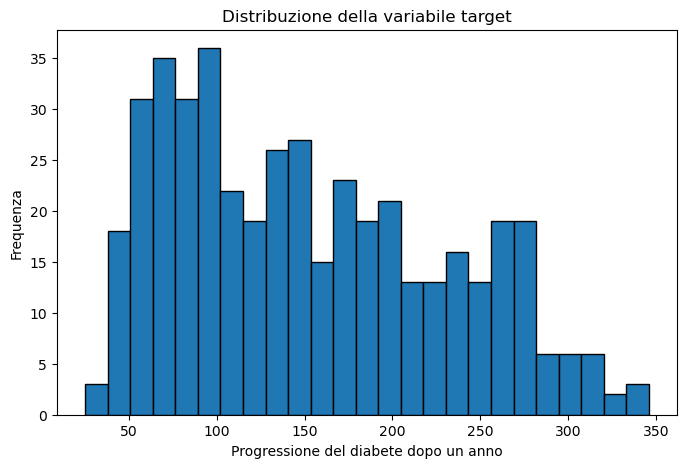

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["target"], bins=25, edgecolor="black")
plt.xlabel("Progressione del diabete dopo un anno")
plt.ylabel("Frequenza")
plt.title("Distribuzione della variabile target")
plt.show()

### Analisi delle correlazioni

Per comprendere quali variabili sono maggiormente associate alla progressione del diabete, viene calcolata una matrice di correlazione tra le feature e la variabile target.

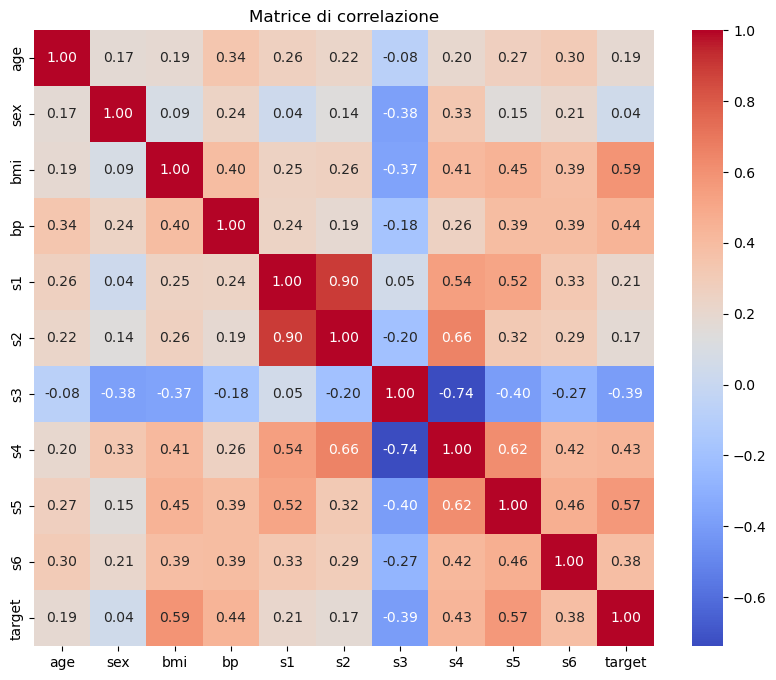

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di correlazione")
plt.show()

### Relazione tra BMI e progressione del diabete

Dalla matrice di correlazione emerge che BMI è la variabile maggiormente correlata con il target.

Il grafico seguente consente di osservare la relazione tra l'indice di massa corporea (BMI) e la progressione del diabete dopo un anno.

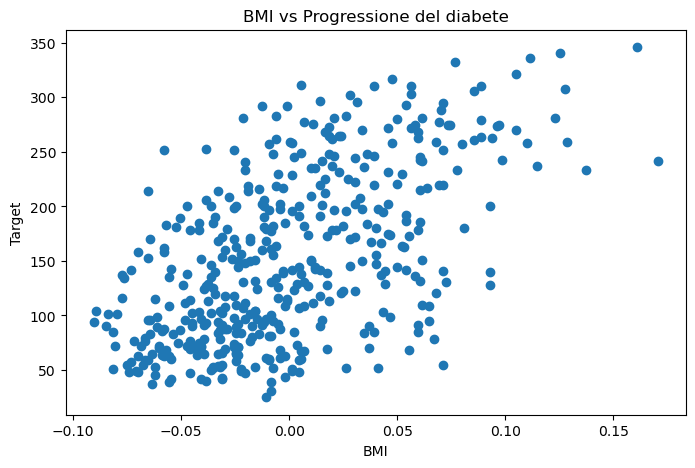

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["bmi"], df["target"])
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Progressione del diabete")
plt.show()


Osservando il grafico si nota una tendenza positiva: valori più elevati di BMI risultano generalmente associati a una maggiore progressione del diabete.

Questo conferma quanto evidenziato dalla matrice di correlazione.

### Relazione tra S5 e progressione del diabete

Anche la variabile S5 mostra una forte correlazione positiva con il target.

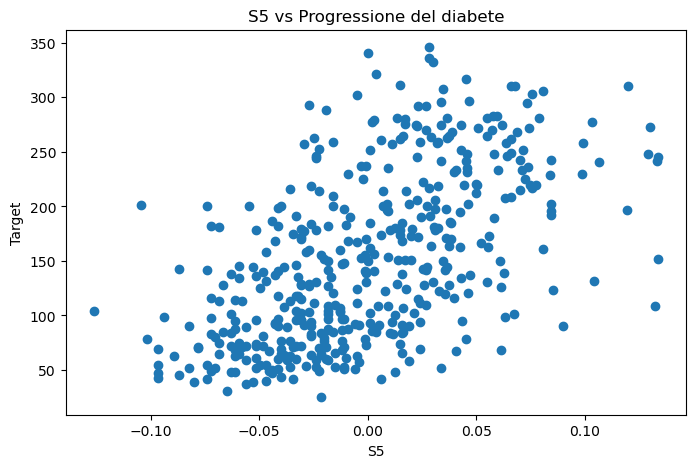

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["s5"], df["target"])
plt.xlabel("S5")
plt.ylabel("Target")
plt.title("S5 vs Progressione del diabete")
plt.show()

### Analisi degli outlier

Per verificare la presenza di possibili valori anomali viene utilizzato un boxplot delle variabili del dataset.

L'obiettivo è identificare eventuali osservazioni estreme che potrebbero influenzare il processo di modellazione.

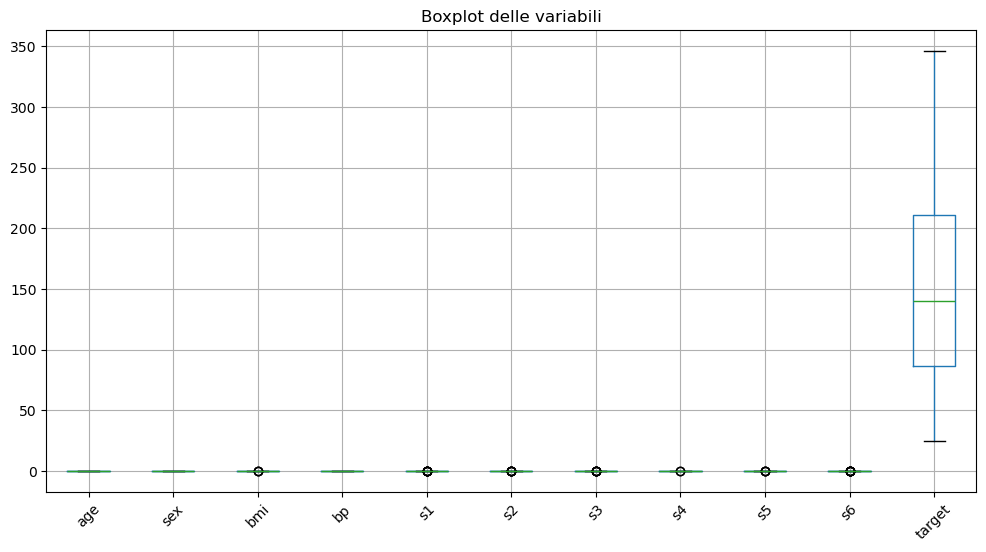

In [10]:
plt.figure(figsize=(12,6))
df.boxplot(rot=45)
plt.title("Boxplot delle variabili")
plt.show()

### Considerazioni sugli outlier

Dall'analisi dei boxplot emergono alcune osservazioni potenzialmente estreme in diverse variabili.

Tuttavia, il numero di outlier risulta limitato e non tale da giustificare la rimozione dei dati.

Poiché il modello Random Forest è relativamente robusto alla presenza di outlier, si è deciso di mantenere tutte le osservazioni nel dataset.

# Feature Engineering e Preprocessing

Prima della modellazione è stata valutata la necessità di applicare tecniche di preprocessing ai dati.

Il dataset Diabetes fornito da Scikit-Learn presenta già variabili standardizzate e centrate rispetto alla media.

Per questo motivo non è stato necessario applicare ulteriori tecniche di scaling come StandardScaler o MinMaxScaler.

L'analisi esplorativa ha inoltre mostrato la presenza di alcuni outlier, ma non in misura tale da richiedere la rimozione delle osservazioni.

Si è quindi deciso di mantenere il dataset nella sua forma originale per la fase di modellazione.

In [11]:
df[['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6']].agg(['mean','std'])

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02


### Considerazioni sul preprocessing

Le medie delle variabili risultano molto vicine a zero e le deviazioni standard sono simili tra loro.

Questo conferma che il dataset è già stato sottoposto a un processo di standardizzazione, rendendo non necessario applicare ulteriori trasformazioni prima dell'addestramento dei modelli.

## Preparazione dei dati

Prima dell'addestramento del modello ho verificato che il dataset non contiene valori mancanti.

Successivamente le variabili indipendenti (X) sono state separate dalla variabile target (y), che rappresenta la progressione del diabete dopo un anno.

Infine ho suddiviso il dataset in Training Set (80%) e Test Set (20%) per valutare la capacità del modello di generalizzare su dati mai visti.

_______________________________________________________________________________________________________________________________________________________


In [12]:
X = df.drop("target", axis=1)
y = df["target"]

print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


# Modello baseline

Prima di utilizzare Random Forest viene addestrato un modello di regressione lineare come riferimento.

Questo permette di verificare se un modello più complesso è realmente in grado di migliorare le prestazioni predittive.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

baseline = LinearRegression()

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_pred)

print("R² Linear Regression:", round(baseline_r2, 3))

R² Linear Regression: 0.453


### Confronto con il modello finale

La Linear Regression ha ottenuto un valore R² pari a 0.453.

Questo risultato viene utilizzato come baseline per valutare l'efficacia del Random Forest Regressor.

Poiché il Random Forest ottimizzato raggiunge un R² pari a 0.476, si osserva un lieve miglioramento delle prestazioni predittive, suggerendo la presenza di relazioni non completamente lineari tra le variabili del dataset.

## Scelta del modello

Per questo progetto è stato scelto Random Forest Regressor poiché è in grado di modellare relazioni non lineari tra le variabili cliniche e la progressione del diabete.

A differenza della regressione lineare, Random Forest combina numerosi alberi decisionali riducendo il rischio di overfitting e migliorando la capacità di generalizzazione.

Per individuare la configurazione ottimale degli iperparametri è stata utilizzata GridSearchCV con validazione incrociata a 5 fold.

## Ottimizzazione degli iperparametri

Per migliorare le prestazioni del modello ho utilizzato la tecnica Grid Search con validazione incrociata a 5 fold.

Sono stati testati diversi valori degli iperparametri `n_estimators` e `max_depth`.

La configurazione migliore trovata è risultata:

- n_estimators = 200
- max_depth = 3

Utilizzerò questa configurazione per effettuare le predizioni sul Test Set.

_______________________________________________________________________________________________________________________________________________________


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Migliori parametri:")
print(grid_search.best_params_)

Migliori parametri:
{'max_depth': 3, 'n_estimators': 200}


In [16]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

## Valutazione del modello

Per valutare le prestazioni del modello ho utilizzato tre metriche:

- R² (Coefficiente di determinazione), che misura la capacità del modello di spiegare la variabilità dei dati.
- MAE (Mean Absolute Error), che rappresenta l'errore medio assoluto delle predizioni.
- RMSE (Root Mean Squared Error), che penalizza maggiormente gli errori più elevati.

Queste metriche consentono di valutare l'accuratezza delle previsioni sul Test Set.

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("R²:", round(r2, 3))
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

R²: 0.476
MAE: 42.714
RMSE: 52.672


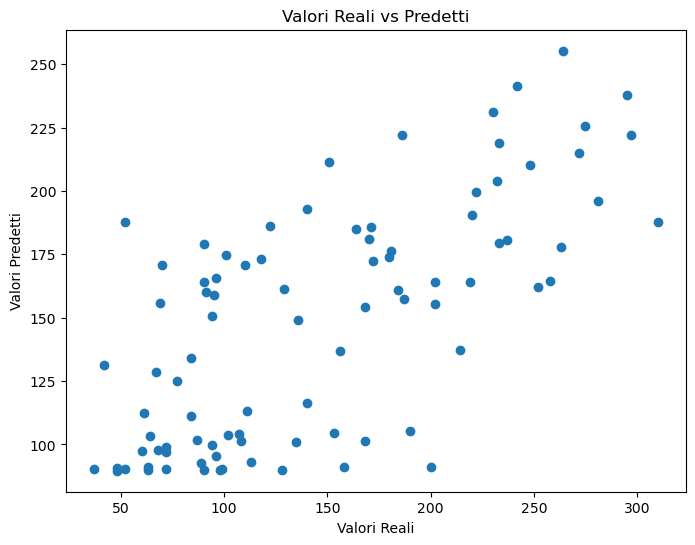

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Valori Reali vs Predetti")
plt.show()

# Conclusioni

In questo progetto ho sviluppato un modello di Machine Learning per prevedere la progressione del diabete utilizzando il dataset Diabetes di Scikit-Learn.

Dopo una fase iniziale di esplorazione e preparazione dei dati, è stato addestrato un modello Random Forest Regressor.

Per migliorare le prestazioni ho effettuato un'ottimizzazione degli iperparametri tramite GridSearchCV, individuando come configurazione migliore:

- n_estimators = 200
- max_depth = 3

Le prestazioni sono state valutate sul Test Set attraverso le metriche R², MAE e RMSE.

Il modello quindi ha mostrato una discreta capacità predittiva, spiegando circa il 48% della variabilità della variabile target e fornendo una base utile per supportare l'analisi della progressione del diabete.